# 다이캐스팅 공정 데이터 기반 품질 예측 프로젝트

- 다이캐스팅은 용융 금속을 금형에 고압으로 주입하여 정밀한 제품을 생산하는 공정이다.
- 생산 효율을 높이고 불량품을 낮추기 위해 공정 변수 및 센서 데이터를 분석해서 불량 유형을 자동 예측하는 머신러닝 모델을 개발해야함.
- 실시간 공정 데이터와 품질 검사를 연계하여 품질 예측 시스템을 구축하고자 함.

# 비즈니스 문제 정의

### 현재 상황

- 불량품이 발생해도 육안 검사에 의존하여 판정 기준의 주관성과 검사 속도의 한계로 생산성이 저하됨.
- 불량 발생 원인을 추적하기 힘들어 공정 개선 및 문제 해결이 어려움.
- 공정 데이터와 품질 검사를 효과적으로 매핑하지 못하여 실시간 품질 관리 및 재발 방지 대책이 부족한 상황.

### 분석 목표

- 다이캐스팅 공정 과정에서 발생하는 다양한 불량 유형을 자동으로 예측해주는 머신 러닝 모델 개발
- 공정 데이터와 센서 데이터를 면밀히 분석해 불량 여부와의 관계성 파악
- 불량 발생의 주요 원인을 분석해서 공정의 최적화를 지원
- 실시간 품질 예측 체계를 구축하여 조기 경보 시스템 도입 및 불량률 감소

### 비즈니스 산출물

1) 불량 발생의 주요 원인을 분석하고 이를 시각화하여 제시
2) 불량 유형을 자동으로 예측해주는 머신러닝 모델 제시

# 데이터셋 구성

- **공정(Process)데이터**
1) Shot ID : 주조 샷 고유 식별자
2) Injection Speed : 용탕 주입 속도 (m/s)
3) Die Temperature : 금형 온도
4) Casting Pressure : 주조 압력 (bar)
5) Cooling Time: 냉각 시간 (s)

- **센서(Sensor) 데이터**
1) Mold Temp Sensor : 금형 내 센서 온도 (°C)
2) Hydraulic Pressure : 유압 압력 (bar)
3) Vibration Sensor : 진동값 (Hz)
4) Flow Rate Sensor : 유량 (L/min)

- **불량(Defects) 데이터**
1) Defect Type : 발생한 불량 유형 (미성형, 박리, 기공, 평탄, 개재물 등)
2) Defect Status : 양품(0) / 불량(1) 여부

In [3]:
# ============================================================
# 공정(Process) 주요 컬럼 설명
# ============================================================
# • Shot ID                       : 주조 번호 (붕어빵 틀에 반죽을 한 번 붓고 뚜껑을 닫는 행위에 관한 일련번호)
# • Injection Speed               : 주입 속도 (쇳물을 금형에 얼마나 빨리 밀어 넣는가)
# • Die Temperature               : 금형 온도 (금형 틀이 어느정도의 온도인가)
# • Casting Pressure              : 주조 압력 (쇳물을 다 채운 뒤 강하게 누르는 힘)
# • Cooling Time                  : 냉각 시간 (액체 상태인 금속이 고체가 될 떄까지 기다리는 힘)


# ============================================================
# 공정(Process) 컬럼별 분석 관점
# ============================================================
# • Injection Speed               : 주입 속도가 너무 느리면 쇳물이 금형으로 가다가 굳어버리고, 너무 빠르면 사방으로 튀어서 속에 공기 방울(기공)이 생길 수 있다.
# • Die Temperature               : 금형 온도가 너무 낮으면 쇳물이 일찍 굳고 너무 높으면 금형 수명이 줄거나 제품이 달라붙는 현상이 생긴다.
# • Casting Pressure              : 압력이 너무 낮으면 기공이 발생할 수 있고, 너무 높으면 금형 손상 및 제품 변형이 일어날 수 있다.
# • Cooling Time                  : 냉각 시간이 너무 짧으면 탈형 시 변형이 오고, 너무 느리면 사이클 타임이 늘어나 생산성이 떨어진다.


# ============================================================
# 센서(Sensor) 주요 컬럼 설명
# ============================================================
# • Mold Temp Sensor               : 금형 내부 온도 (Die Temperature가 전체의 겉 온도라면, 이거는 틀 안쪽 깊숙한 곳의 실시간 온도이다)
# • Hydraulic Pressure             : 유압 압력 (bar) (쇳물을 밀어내기 위해 기계 팔(실린더)이 쓰는 기름의 힘 혈압과 비슷하다고 볼 수 있음)
# • Vibration Sensor               : 진동값 (Hz) (기계가 작동할 떄의 떨림)
# • Flow Rate Sensor               : 유량 (L/min) (틀을 식히기 위한 냉각수가 흐르는 속도를 나타냄)


# ============================================================
# 센서(Sensor) 컬럼별 분석 관점
# ============================================================
# • Mold Temp Sensor               : 쇳물이 들어올 때 순간 확 올랐다가 식으면서 툭 떨어지는 경향을 보인다
# • Hydraulic Pressure             : 유압 압력은 혈압과 비슷하다고 생각할 수 있다. 유압 압력이 일정해야 쇳물을 쏘아 주는 힘이 균일해진다.
# • Vibration Sensor               : 평소보다 많이 흔들린다면 나사가 풀렸거나, 부품이 마모됐거나, 쇳물이 튀어서 어딘가 걸렸다는 신호일 수 있다.
# • Flow Rate Sensor               : 유량이 적으면 틀이 식지 않아서 제품이 녹아내릴 수 있다.


# ============================================================
# 불량(Defects) 주요 컬럼 설명
# ============================================================
# • Defect Type                   : 발생한 불량 유형
# • Defect Status                 : 양품(0) / 불량(1) 여부


# ============================================================
# 불량(Defects) 유형 설명
# ============================================================
# • 미성형 (Underfill/Short Shot)  : 반죽이 모자라 다 완성되지 못한 붕어빵 (주입 속도가 느리거나, 금형 온도가 낮을 때 주로 발생) -> Injection Speed, Mold Temp Sensor
# • 박리 (Lamination/Peeling)      : 금속 층이 서로 제대로 붙지 않고 겹쳐진 상태 (쇳물이 들어갈 때 너무 차갑거나, 불순물이 섞여 층이 생기면 발생) -> Mold Temp Sensor, Flow Rate Sensor
# • 기공 (Porosity/Gas Hole)       : 공기 방울이 송송 뚫린 상태(주조 압력이 너무 낮거나, 주입 속도가 너무 빨라서 공기가 들어갔을 때 생김) -> Casting Pressure, Injection Speed
# • 평탄 (Flatness Error)          : 바닥이 평평하지 않고 휘어진 붕어빵 (냉각 시간이 너무 짧거나, 냉각수가 골고루 잘 흐르지 못했을 때 발생) -> Cooling Time, Flow Rate Sensor
# • 개재물 (Inclusion)             : 반죽에 검은 가루나 돌멩이가 들어간 것 (재료 관리가 안되었거나, 필터에 문제가 있을 때 발생) -> Flow Rate Sensor

---
# 1.1 필요 라이브러리 및 폰트 로드

In [36]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)


라이브러리 로드 완료!
한글 폰트 설정 완료!


# 1.2 데이터 로드

In [37]:
# 전체 데이터 셋
df_original = pd.read_csv(r"C:\Users\rmstn\sparta-data11-advanced-project\Geunsu\data\DieCasting_Quality_Raw_Data.csv", header=[0,1])

# 제품 타입 1번 데이터 추출
df_product_1 = df_original.loc[df_original[('Process', 'Product_Type')] == 1].copy()

# 제품 타입 2번 데이터 추출
df_product_2 = df_original.loc[df_original[('Process', 'Product_Type')] == 2].copy()


# 컬럼명 중 첫번째 행을 기준으로 컬럼 분리
process_cols = [col for col in df_product_1.columns if col[0] == 'Process']
sensor_cols = [col for col in df_product_1.columns if col[0] == 'Sensor']
defects_cols = [col for col in df_product_1.columns if col[0] == 'Defects']

# 데이터 프레임 생성
df_process = df_product_1[process_cols].copy()
df_sensor = df_product_1[sensor_cols].copy()
df_defects = df_product_1[defects_cols].copy()

# 두 번째 행에 있는 컬럼명만 사용하도록 변경
# get_level_values(가져오고 싶은 레벨 인덱스) - level 0: 첫번째 행, level 1: 두번째 행
# 왼쪽 .columns: 컬럼명을 바꾸기 위한 설정
# 오른쪽 .columns: 기존 다중레벨 컬럼 가져오기 → get_level_values(1)로 Level 1만 추출
df_process.columns = df_process.columns.get_level_values(1)
df_sensor.columns = df_sensor.columns.get_level_values(1)
df_defects.columns = df_defects.columns.get_level_values(1)

---

# 2 데이터 전처리 (Data Preprocessing)

### 2.1 중복 데이터 확인

In [17]:
# 전체 행에 대한 중복값 확인 -> 완전히 동일한 행이 있는지 확인하는 용도
print(f"전체 행에 대한 데이터 중복값 : {df_original.duplicated().sum()}건")

# 각 테이블의 ID 기준에 대한 중복값 확인 -> 설비 ID 중복 확인용
print(f"ID 기준에 대한 중복값 : {df_process.duplicated(subset=["id"]).sum()}건")


전체 행에 대한 데이터 중복값 : 0건
ID 기준에 대한 중복값 : 0건


### 2.2 데이터 타입 확인

In [19]:
# 각 테이블의 데이터 형식 확인
display(df_process.dtypes)
display(df_sensor.dtypes)
display(df_defects.dtypes)

id                       int64
Product_Type             int64
Shot                     int64
Velocity_1             float64
Velocity_2             float64
Velocity_3             float64
High_Velocity          float64
Cylinder_Pressure        int64
Rapid_Rise_Time        float64
Biscuit_Thickness        int64
Clamping_Force           int64
Cycle_Time             float64
 Pressure_Rise_Time    float64
Casting_Pressure         int64
Spray_Time             float64
Spray_1_Time           float64
Spray_2_Time           float64
dtype: object

Melting_Furnace_Temp    float64
Air_Pressure            float64
Air_Pressure_Min          int64
Air_Pressure_Max          int64
Coolant_Temp            float64
Coolant_Temp_Min          int64
Coolant_Temp_Max          int64
Coolant_Pressure        float64
Factory_Temp            float64
Factory_Temp_Min        float64
Factory_Temp_Max        float64
Factory_Humidity        float64
Factory_Humidity_Min    float64
Factory_Humidity_Max    float64
dtype: object

Short_Shot_1       int64
Bubble_1           int64
Exfoliation_1      int64
Blow_Hole_1        int64
Stain_1            int64
Dent_1             int64
Deformation_1      int64
Contamination_1    int64
Impurity_1         int64
Crack_1            int64
Scratch_1          int64
Buring_Mark_1      int64
Inclusions_1       int64
Short_Shot_2       int64
Bubble_2           int64
Exfoliation_2      int64
Blow_Hole_2        int64
Stain_2            int64
Dent_2             int64
Deformation_2      int64
Contamination_2    int64
Impurity_2         int64
Crack_2            int64
Scratch_2          int64
Buring_Mark_2      int64
Inclusions_2       int64
dtype: object

### 2.3 컬럼 정제

In [20]:
df_process.columns = df_process.columns.astype("str").str.strip().str.lower()
df_sensor.columns = df_sensor.columns.astype("str").str.strip().str.lower()
df_defects.columns = df_defects.columns.astype("str").str.strip().str.lower()

In [21]:
# Sensor에서 _min/_max로 끝나는 컬럼 찾아서 삭제
minmax_cols = [c for c in df_sensor.columns if c.endswith("_min") or c.endswith("_max")]
df_sensor_clean = df_sensor.drop(columns=minmax_cols)


print("삭제한 _min/_max 컬럼 수:", len(minmax_cols))
print("삭제 전 df_sensor shape:", df_sensor.shape)
print("삭제 후 df_sensor shape:", df_sensor_clean.shape)

삭제한 _min/_max 컬럼 수: 8
삭제 전 df_sensor shape: (4207, 14)
삭제 후 df_sensor shape: (4207, 6)


### 2.4 불량 유형 고유값 처리

In [22]:
# 1. 1 이상의 고윳값들이 존재하는 컬럼들
target_columns = [
    "short_shot_1", "exfoliation_1", "blow_hole_1", "stain_1", "deformation_1",
    "short_shot_2", "bubble_2", "exfoliation_2", "blow_hole_2", "deformation_2"
]
# 2. 1 이상의 값을 모두 1로 변환
df_defects[target_columns] = df_defects[target_columns].clip(upper=1)

# 3. 결과 확인 (고유값이 [0, 1]로 정리되었는지 확인)
print("변환 후 고유값 확인:")
for col in df_defects:
    print(f"{col}: {df_defects[col].unique()}")

변환 후 고유값 확인:
short_shot_1: [0 1]
bubble_1: [0 1]
exfoliation_1: [0 1]
blow_hole_1: [0]
stain_1: [0 1]
dent_1: [0 1]
deformation_1: [0 1]
contamination_1: [0]
impurity_1: [0]
crack_1: [0]
scratch_1: [0]
buring_mark_1: [0]
inclusions_1: [0]
short_shot_2: [0 1]
bubble_2: [0 1]
exfoliation_2: [0 1]
blow_hole_2: [0]
stain_2: [0]
dent_2: [0]
deformation_2: [0 1]
contamination_2: [0]
impurity_2: [0]
crack_2: [0]
scratch_2: [0]
buring_mark_2: [0]
inclusions_2: [0]


In [23]:
# Cavity 1,2 불량 유형 통합
# 원본 보관
df_defects_clean =df_defects.copy()

# cavity 1/2 컬럼 분리
c1 =df_defects_clean[[c for c in df_defects_clean.columns if c.endswith("_1")]].copy()
c2 =df_defects_clean[[c for c in df_defects_clean.columns if c.endswith("_2")]].copy()

# 컬럼명 통일: Short_Shot_1 -> Short_Shot
c1.columns = [c.replace("_1", "") for c in c1.columns]
c2.columns = [c.replace("_2", "") for c in c2.columns]

# 제대로 분리되었는지 확인
print("c1 shape:", c1.shape)
print("c2 shape:", c2.shape)
print("c1, c2 컬럼이 동일한가?", set(c1.columns) == set(c2.columns))

c1 shape: (4207, 13)
c2 shape: (4207, 13)
c1, c2 컬럼이 동일한가? True


In [24]:
# OR 방식으로 통합: 둘 중 하나라도 1이면 1
defects_merged = ((c1 + c2) > 0).astype(int)   # (c1 | c2) 도 가능
df_defects_clean = defects_merged

print("통합 전 df_defects shape:",df_defects.shape)
print("통합 후 df_defects_clean shape:",df_defects_clean.shape)
print("값 종류:", np.unique(df_defects_clean.to_numpy()))
df_defects_clean.head(20)

통합 전 df_defects shape: (4207, 26)
통합 후 df_defects_clean shape: (4207, 13)
값 종류: [0 1]


,short_shot,bubble,exfoliation,blow_hole,stain,dent,deformation,contamination,impurity,crack,scratch,buring_mark,inclusions
0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,1,0,0,0,0,0,0


In [25]:
# 전체 셀 기준(모든 defect 칸을 다 펼쳐서 0/1/2 비율)
flat = df_defects_clean.to_numpy().ravel()
dist_all = pd.Series(flat).value_counts(normalize=True).reindex([0,1,2], fill_value=0)
print("=== 전체 셀 기준 0/1/2 비율 ===")
print((dist_all * 100).round(2).astype(str) + "%")

=== 전체 셀 기준 0/1/2 비율 ===
0    98.58%
1     1.42%
2      0.0%
Name: proportion, dtype: object


### 2.5 불량 유형 분리
- 표면 불량(surface_defect) : 육안으로 확인 가능하지만, 금속의 분리나 갈라짐은 없는 불량 (Stain, Dent, Scratch, Burning_Mark)
- 구조 불량(structural_defect): 육안으로 금속의 분리·갈라짐이 보이거나, 제품의 강도·기능에 직접 영향을 줄 수 있는 불량 (Short_Shot, Bubble, Blow_Hole, Deformation, Crack, Exfoliation)
- 이물질 포함 불량(contamination_defect): 원래 포함되면 안 되는 외부 물질이 들어간 불량 (Contamination, Impurity, Inclusions)

In [ ]:
# 1) 그룹 정의
# 그룹별 OR(하나라도 1이면 1)로 합치기
group_df = pd.DataFrame(index=df_defects_clean.index)

group_df["surface_defect"] = ( # 표면 불량
    df_defects_clean.reindex(columns=["stain", "dent", "scratch", "burning_Mark"], fill_value=0).max(axis=1)
)

group_df["structural_defect"] = ( # 구조 불량
    df_defects_clean.reindex(columns=["short_shot", "bubble", "blow_hole", "deformation", "crack", "exfoliation"], fill_value=0).max(axis=1)
)

group_df["contamination_defect"] = ( # 이물질 포함 불량
    df_defects_clean
    .reindex(columns=["contamination", "impurity", "inclusions"], fill_value=0)
    .max(axis=1)
)

print("group_df shape:", group_df.shape)
print("\n고유값 종류:", np.unique(group_df.to_numpy()))
display(group_df.sum().sort_values(ascending=False)) # 각 유형별 불량 개수
group_df.info()

group_df shape: (4207, 3)

고유값 종류: [0 1]


structural_defect       735
surface_defect            6
contamination_defect      0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
Index: 4207 entries, 0 to 4206
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   surface_defect        4207 non-null   int64
 1   structural_defect     4207 non-null   int64
 2   contamination_defect  4207 non-null   int64
dtypes: int64(3)
memory usage: 131.5 KB


### 2.6 Shot ID 컬럼 통합

In [27]:
# 1) shot_key 생성
df_process_clean =df_process.copy()
df_process_clean["shot_key"] =df_process_clean["id"].astype(str) + "_" + df_process_clean["shot"].astype(str)

# 2) id, Shot 삭제
df_process_clean =df_process_clean.drop(columns=["id", "shot"])

# 3) shot_key를 맨 앞으로 이동
cols = ["shot_key"] + [c for c in df_process_clean.columns if c != "shot_key"]
df_process_clean =df_process_clean[cols]

# 중복이 있으면 어떤 게 중복인지(있을 때만 의미 있음)
dup =df_process_clean["shot_key"][df_process_clean["shot_key"].duplicated(keep=False)]
print("중복 개수:", dup.shape[0])

중복 개수: 0


In [29]:
clean_df = pd.concat([df_process_clean, df_sensor_clean, group_df], axis=1)

print("clean_df shape:", clean_df.shape)
clean_df.head()

clean_df shape: (4207, 25)


,shot_key,product_type,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,surface_defect,structural_defect,contamination_defect
0,1_1,1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8,695.0,6.3,26.0,2.71,32.9,58.4,0,0,0
1,1002_2,1,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,0,0
2,2003_3,1,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,0,0
3,3004_4,1,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,1,0
4,4005_5,1,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,697.9,6.4,26.1,2.69,32.9,57.8,0,0,0


### 2.7 결측값 처리

In [18]:
na_count = clean_df.isna().sum().sort_values(ascending=False)
na_cols = na_count[na_count > 0].sort_values(ascending=False)

print("그룹별 결측치 합(총 결측 수):")
print(pd.Series({
    "Process": df_process_clean.isna().sum().sum(),
    "Sensor":  df_sensor_clean.isna().sum().sum(),
    "Defects": df_defects_clean.isna().sum().sum()
}))
print()

print("결측치가 있는 컬럼만(개수):")
print(na_cols.sort_values(ascending=False))
print()

그룹별 결측치 합(총 결측 수):
Process      0
Sensor     180
Defects      0
dtype: int64

결측치가 있는 컬럼만(개수):
factory_humidity    90
factory_temp        90
dtype: int64



In [19]:
# 결측치가 있는 데이터 행 확인
nan_rows = df_sensor_clean[df_sensor_clean.isna().any(axis=1)]
display(nan_rows.head(10))

,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity
6913,659.5,6.8,27.4,2.62,NaN,NaN
6914,659.5,6.8,27.4,2.62,NaN,NaN
6915,659.5,6.8,27.4,2.62,NaN,NaN
6916,659.5,6.8,27.4,2.62,NaN,NaN
6917,660.1,6.9,27.4,2.64,NaN,NaN
6918,660.1,6.9,27.4,2.64,NaN,NaN
6919,660.8,6.9,27.4,2.63,NaN,NaN
6920,660.8,6.9,27.4,2.63,NaN,NaN
6921,660.8,6.9,27.4,2.63,NaN,NaN
6922,660.8,6.9,27.4,2.63,NaN,NaN


### 2.7.1 선형 보간으로 온도, 습도를 채우기 전의 시각화 그래프

In [20]:
# 1. 최대/최소값 컬럼 결측치 채우기
# 전체 기간의 고정값으로 채우기
target_minmax_cols = [
    'factory_temp_max', 'factory_humidity_max', 
    'factory_humidity_min', 'factory_temp_min'
]
# 최빈값 기준
for col in target_minmax_cols:
    fill_value = df_sensor[col].mode()[0] 
    df_sensor[col] = df_sensor[col].fillna(fill_value)

# 3. 최종 결과 확인
print("결측치 처리 후 남은 개수:")
print(df_sensor[target_minmax_cols].isnull().sum())

결측치 처리 후 남은 개수:
factory_temp_max        0
factory_humidity_max    0
factory_humidity_min    0
factory_temp_min        0
dtype: int64


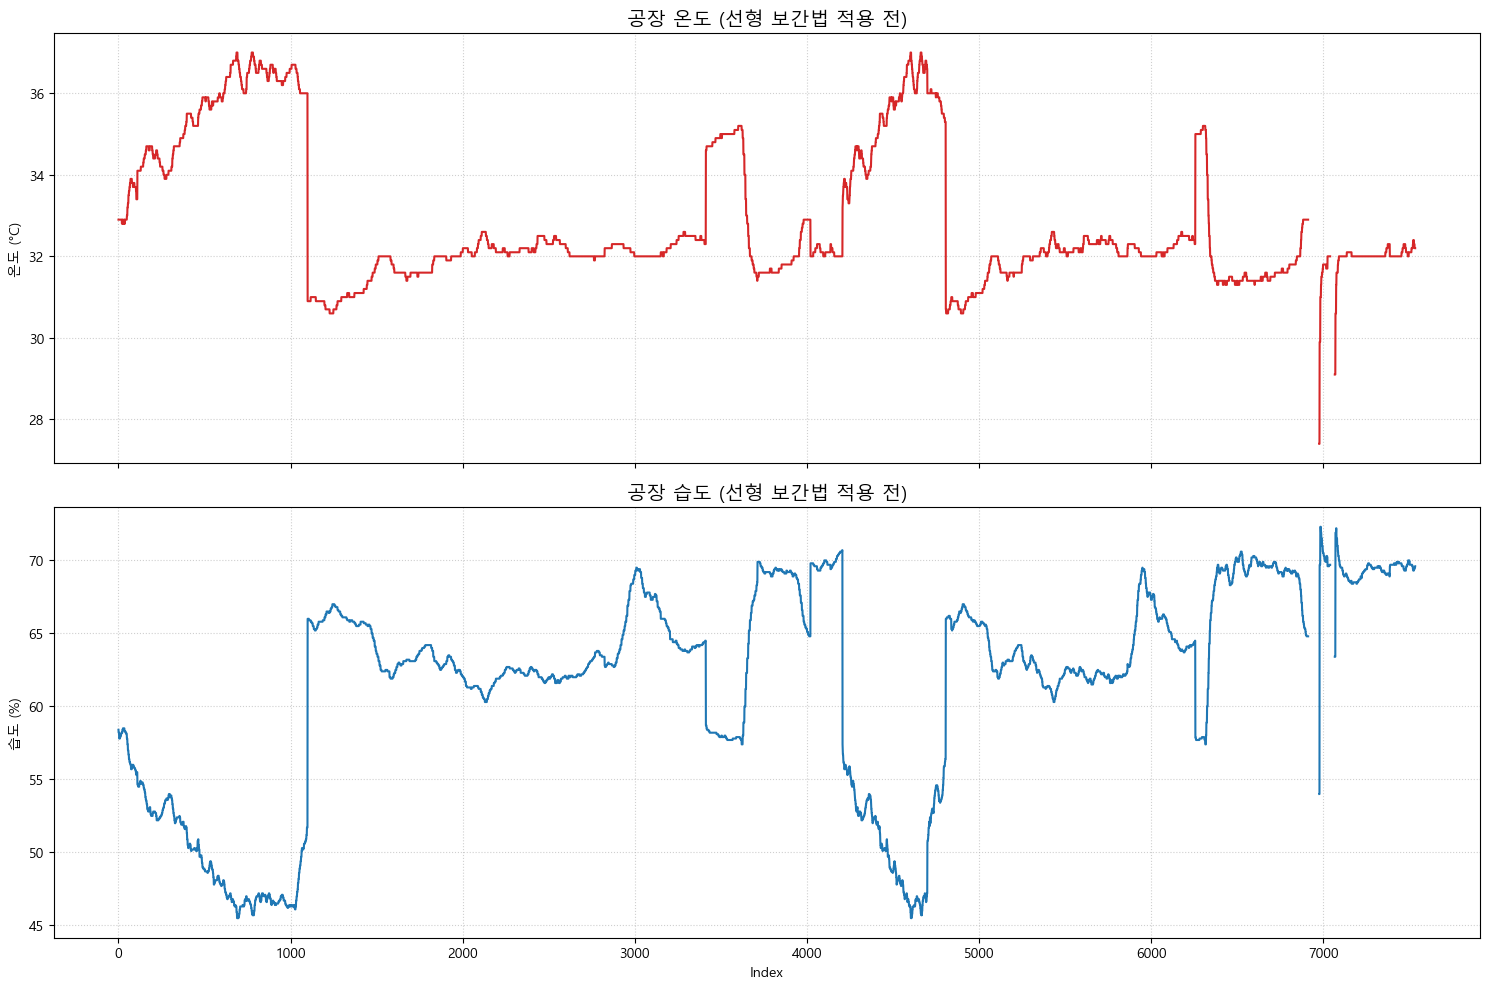

In [21]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# 1. 공장 온도 시각화

ax1.plot(df_sensor_clean.index, df_sensor_clean['factory_temp'], color='tab:red', linewidth=1.5)
ax1.set_title('공장 온도 (선형 보간법 적용 전)', fontsize=14)
ax1.set_ylabel('온도 (°C)')
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. 공장 습도 시각화
ax2.plot(df_sensor_clean.index, df_sensor_clean['factory_humidity'], color='tab:blue', linewidth=1.5)
ax2.set_title('공장 습도 (선형 보간법 적용 전)', fontsize=14)
ax2.set_ylabel('습도 (%)')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.xlabel('Index')
plt.tight_layout()
plt.show()

### 2.7.2. 선형보간법으로 결측치 대체

In [22]:
# 선형 보간법으로 결측치 채우기

df_sensor_clean['factory_temp'] = df_sensor_clean['factory_temp'].interpolate(method='linear', limit_direction='both')
df_sensor_clean['factory_humidity'] = df_sensor_clean['factory_humidity'].interpolate(method='linear', limit_direction='both')

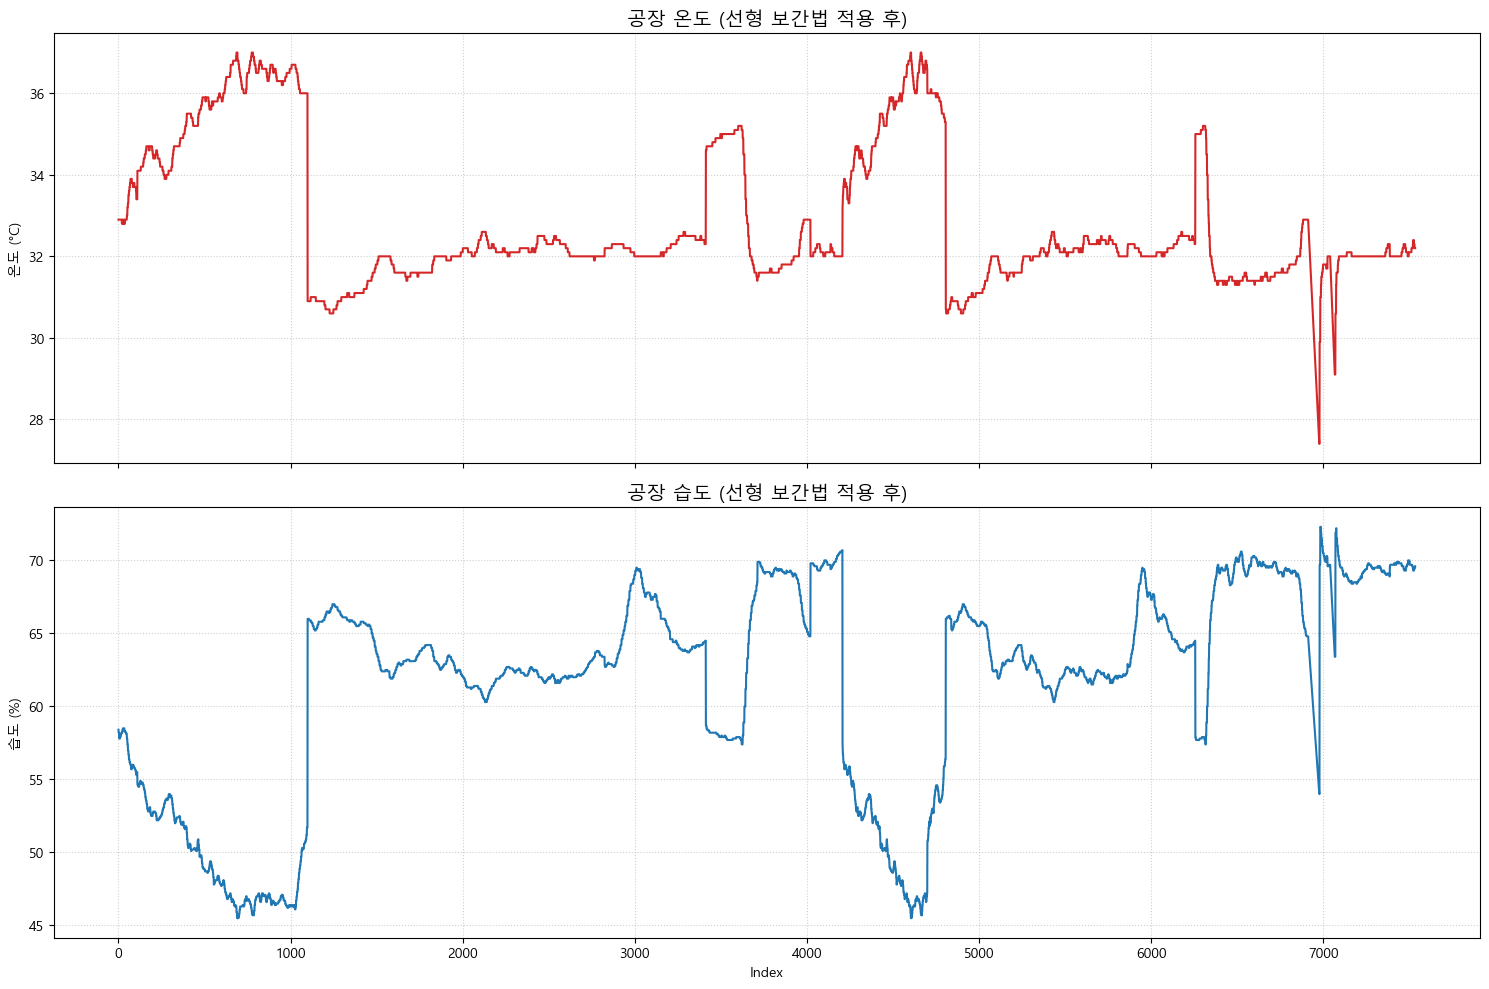

In [23]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# 1. 공장 온도 시각화

ax1.plot(df_sensor_clean.index, df_sensor_clean['factory_temp'], color='tab:red', linewidth=1.5)
ax1.set_title('공장 온도 (선형 보간법 적용 후)', fontsize=14)
ax1.set_ylabel('온도 (°C)')
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. 공장 습도 시각화
ax2.plot(df_sensor_clean.index, df_sensor_clean['factory_humidity'], color='tab:blue', linewidth=1.5)
ax2.set_title('공장 습도 (선형 보간법 적용 후)', fontsize=14)
ax2.set_ylabel('습도 (%)')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.xlabel('Index')
plt.tight_layout()
plt.show()

### 2.8 머신러닝용 데이터셋 저장 (.csv)

In [24]:
clean_df.to_csv("../common-file/for_ML_overall.csv")
df_process_clean.to_csv("../common-file/for_ML_process_data.csv")
df_sensor_clean.to_csv("../common-file/for_ML_sensor_data.csv")
df_defects_clean.to_csv("../common-file/for_ML_defects_data.csv")

### 2.9 이상치 처리

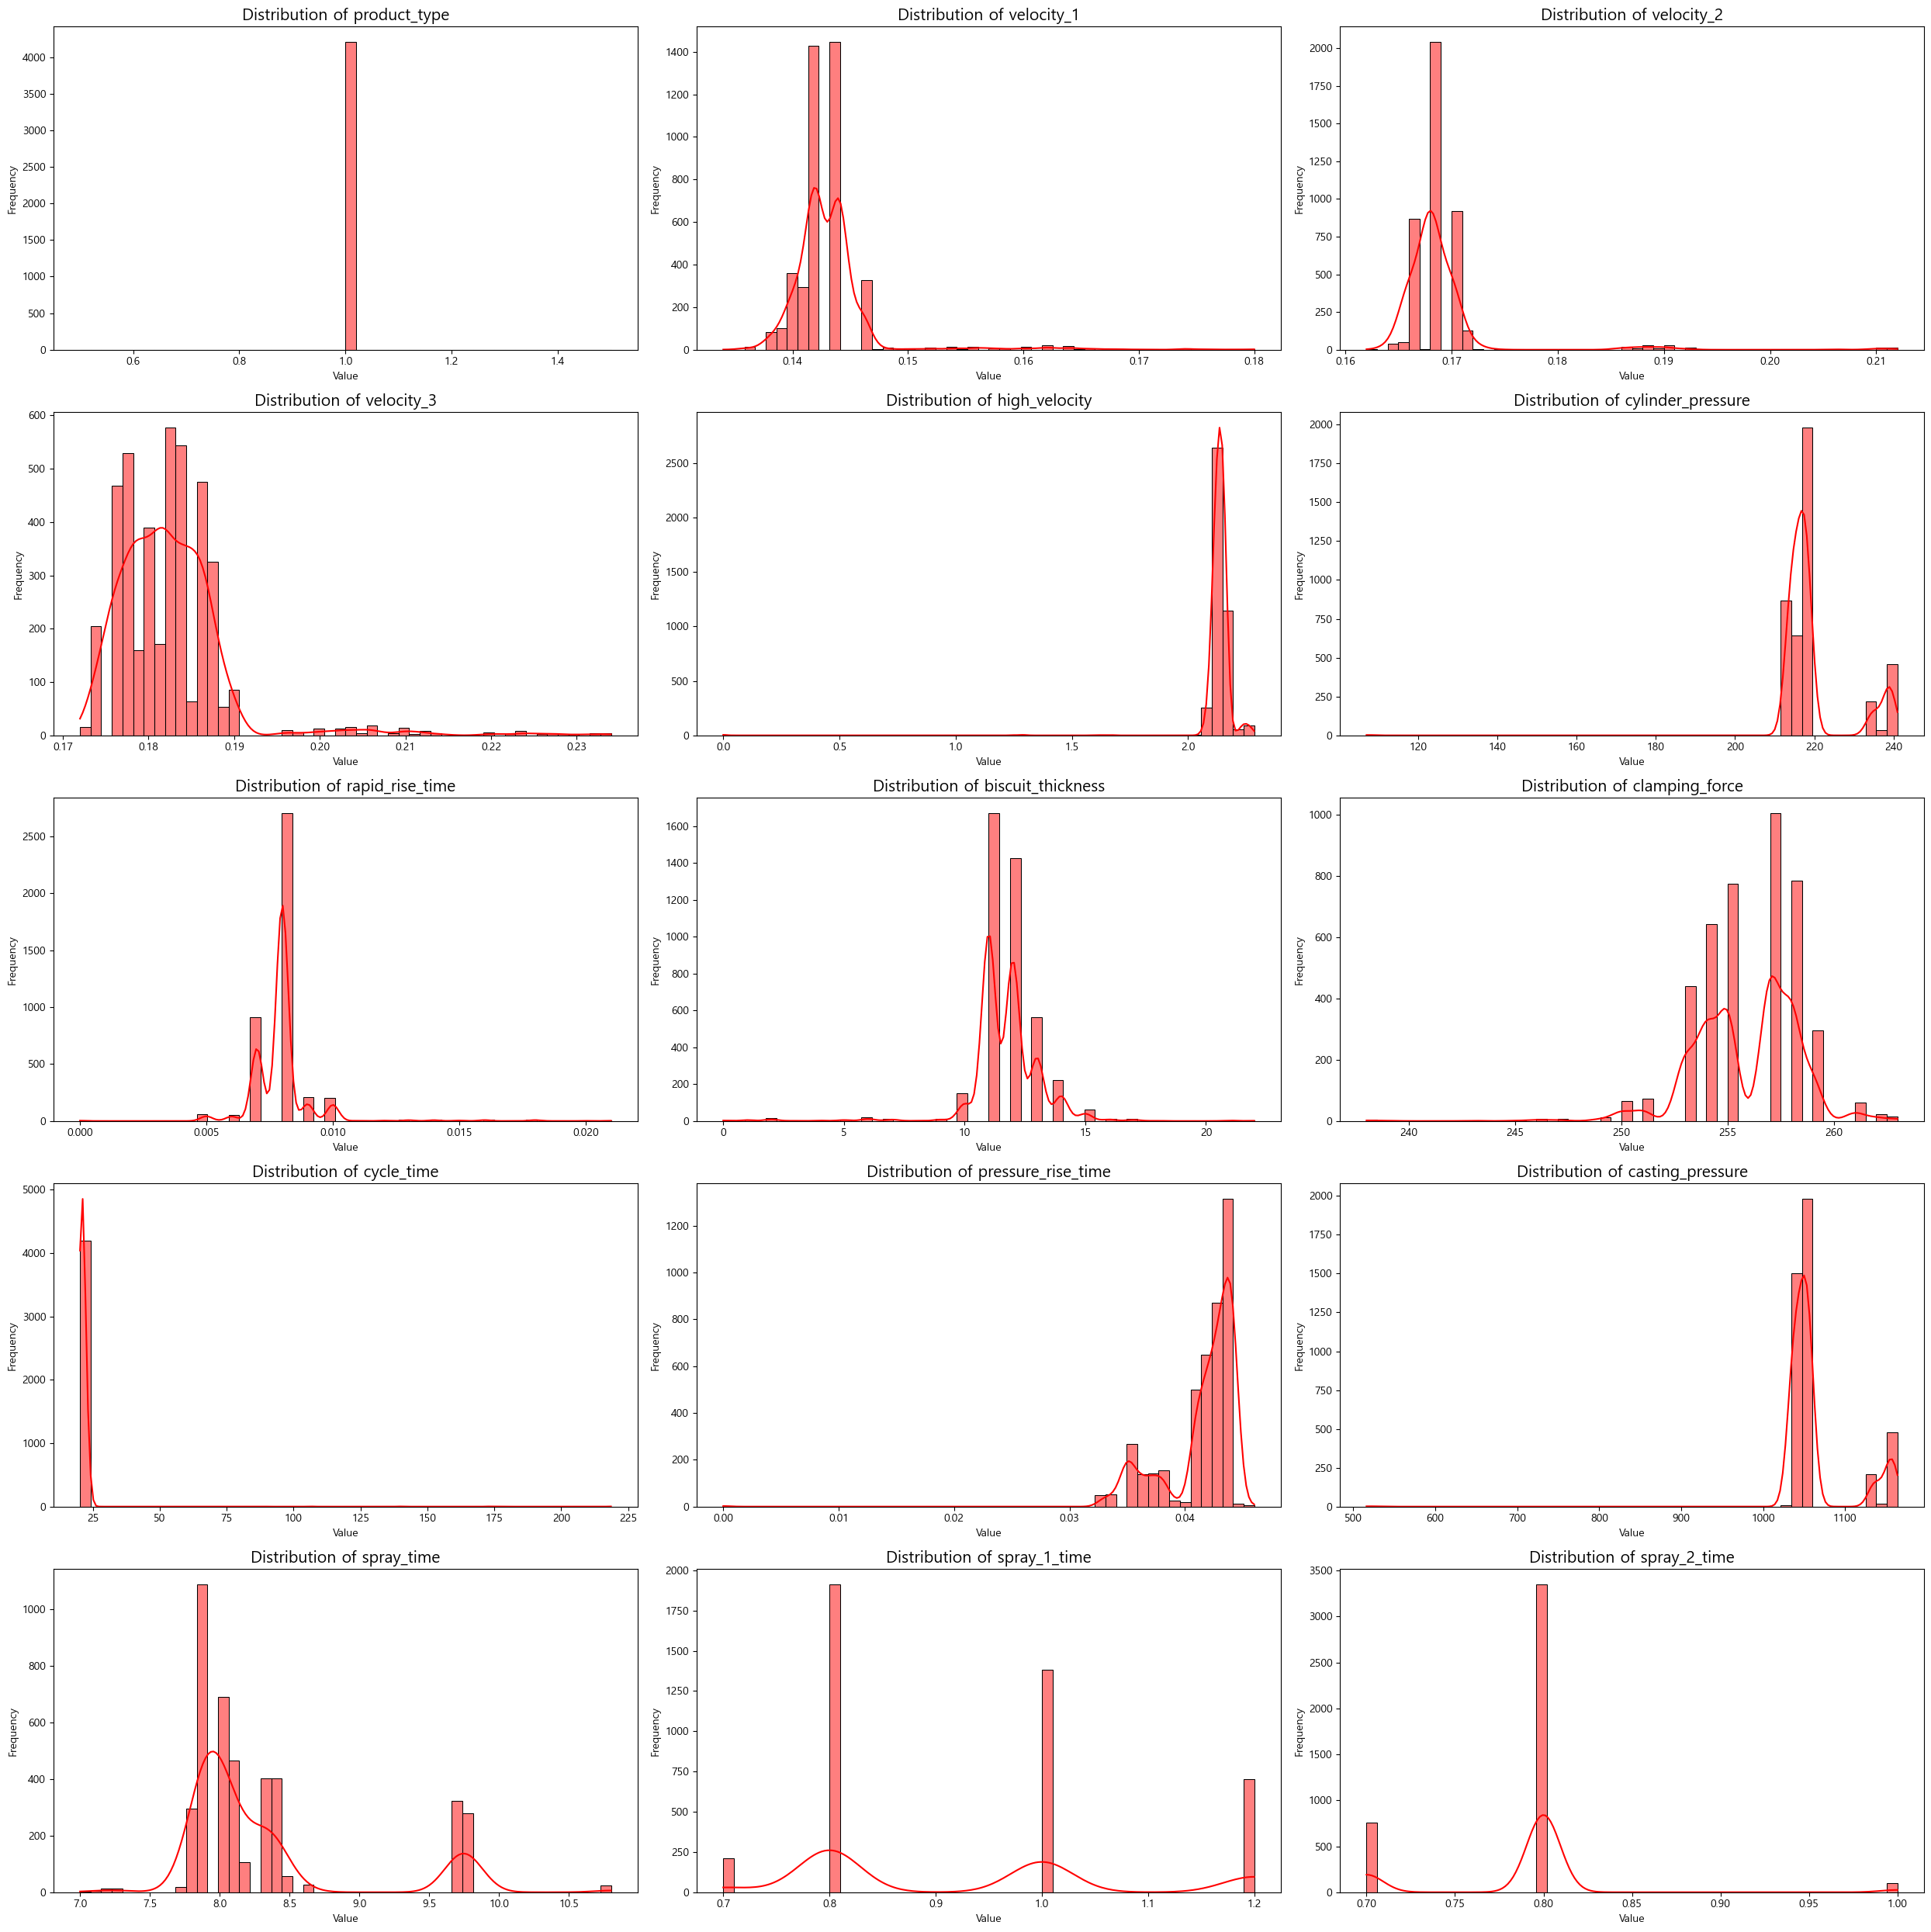

In [30]:
# 1. 수치형 컬럼
numeric_cols = df_process_clean.select_dtypes(include=['number']).columns
n_cols = 3
n_rows = (len(numeric_cols) - 1) // n_cols + 1

plt.figure(figsize=(25, n_rows * 5))
plt.subplots_adjust(hspace=0.4)

for i, col_name in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_process_clean[col_name], kde=True, color='red', bins=50)
    plt.title(f'Distribution of {col_name}', fontsize=15)
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [30]:
def flag_outliers_iqr(df):
    """IQR 방식 플래깅, 전체 데이터 프레임에 적용"""
    
    df_flagged = df.copy()
    
    numeric_cols = df.select_dtypes(include=["number"]).columns # 숫자형 컬럼만 선택
    
    for column in numeric_cols:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
    
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
    
        # 플래그 컬럼 추가(이상치라면 1, IQR 범위 내에 속한다면 0)
        df_flagged[f'{column}_outlier_flag'] = (
            (df[column] < lower_bound) | (df[column] > upper_bound) # OR연산으로 조건 추가
        ).astype(int) # True, False가 1/0으로 출력
    
    return df_flagged

In [41]:
# 1. 수치형 컬럼 선택
df_process_numeric = df_process_clean.select_dtypes(include=['number'])
col = df_process_numeric.columns

# 2. 이상치 개수를 저장할 딕셔너리
outlier_counts = {}

for col in df_process_numeric.columns:
    Q1 = df_process_numeric[col].quantile(0.25)
    Q3 = df_process_numeric[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 임계값 계산
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 이상치 판정 및 개수 합산
    outliers = df_process_numeric[(df_process_numeric[col] < lower_bound) | (df_process_numeric[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

# 3. 결과 출력
outlier_summary = pd.Series(outlier_counts).sort_values(ascending=False)
print(outlier_summary)

# 4. 비율 확인
outlier_ratio = (outlier_summary / len(df_process_clean) * 100).round(2)
print("\n-1- 전체 데이터 대비 이상치 비율 (%) ---")
print(outlier_ratio.head(10))

velocity_2            184
biscuit_thickness      12
cycle_time             11
rapid_rise_time        10
high_velocity          10
velocity_1              6
velocity_3              4
pressure_rise_time      4
cylinder_pressure       4
product_type            0
clamping_force          0
casting_pressure        0
spray_time              0
spray_1_time            0
spray_2_time            0
dtype: int64

-1- 전체 데이터 대비 이상치 비율 (%) ---
velocity_2            2.44
biscuit_thickness     0.16
cycle_time            0.15
rapid_rise_time       0.13
high_velocity         0.13
velocity_1            0.08
velocity_3            0.05
pressure_rise_time    0.05
cylinder_pressure     0.05
product_type          0.00
dtype: float64


In [42]:
df_process_clean.describe()

,product_type,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time
count,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000
mean,1.441672,0.148219,0.168801,0.191193,2.319210,239.655607,0.009596,14.309622,306.433311,27.735979,0.039348,856.944127,9.815979,1.409104,1.396045
std,0.496619,0.007134,0.004720,0.011563,0.222041,23.305451,0.002148,3.286284,57.274965,8.716156,0.003945,234.815490,1.842438,0.557060,0.716170
min,1.000000,0.134000,0.158000,0.172000,0.000000,107.000000,0.000000,0.000000,238.000000,20.200000,0.000000,516.000000,7.000000,0.700000,0.700000
25%,1.000000,0.142000,0.166000,0.181000,2.134000,217.000000,0.008000,11.000000,255.000000,20.900000,0.036000,596.000000,8.000000,0.800000,0.800000
50%,1.000000,0.144000,0.168000,0.188000,2.161000,239.000000,0.009000,13.000000,258.000000,22.600000,0.041000,1037.000000,9.700000,1.200000,0.800000
75%,2.000000,0.156000,0.170000,0.202000,2.523000,265.000000,0.012000,17.000000,372.000000,35.900000,0.043000,1053.000000,12.100000,2.000000,2.000000
max,2.000000,0.180000,0.212000,0.234000,2.744000,266.000000,0.021000,24.000000,388.000000,218.600000,0.046000,1164.000000,13.100000,2.500000,3.000000


In [44]:
import pandas as pd

# 1. 수치형 컬럼 선택
numeric_cols = df_process_clean.select_dtypes(include=['number']).columns

boundary_list = []

for col in numeric_cols:
    Q1 = df_process_clean[col].quantile(0.25)
    Q3 = df_process_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 임계값 계산
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    boundary_list.append({
        'Column': col,
        'Q1 (25%)': round(Q1, 4),
        'Q3 (75%)': round(Q3, 4),
        'Lower_Bound': round(lower_bound, 4),
        'Upper_Bound': round(upper_bound, 4)
    })

# 2. 결과 출력 (가독성을 위해 데이터프레임 변환)
boundary_df = pd.DataFrame(boundary_list).set_index('Column')
print("--- 컬럼별 IQR 이상치 경계값 (Boundary) ---")
display(boundary_df) # 주피터 노트북 환경이라면 display()가 더 예쁘게 나옵니다.

--- 컬럼별 IQR 이상치 경계값 (Boundary) ---


,Q1 (25%),Q3 (75%),Lower_Bound,Upper_Bound
Column,,,,
product_type,1.000,2.000,-0.5000,3.5000
velocity_1,0.142,0.156,0.1210,0.1770
velocity_2,0.166,0.170,0.1600,0.1760
velocity_3,0.181,0.202,0.1495,0.2335
high_velocity,2.134,2.523,1.5505,3.1065
cylinder_pressure,217.000,265.000,145.0000,337.0000
rapid_rise_time,0.008,0.012,0.0020,0.0180
biscuit_thickness,11.000,17.000,2.0000,26.0000
clamping_force,255.000,372.000,79.5000,547.5000


In [33]:
outlier_col_list = outlier_summary[outlier_summary > 0].index.tolist()
print("컬럼 리스트:", outlier_col_list)

컬럼 리스트: ['velocity_2', 'biscuit_thickness', 'cycle_time', 'rapid_rise_time', 'high_velocity', 'velocity_1', 'velocity_3', 'pressure_rise_time', 'cylinder_pressure']


In [34]:
# 혹시 모르니 복사본 만듦
df_cleaned = df_process_clean.copy()
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns

for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_cleaned.loc[df_cleaned[col] < lower_bound, col] = lower_bound
    df_cleaned.loc[df_cleaned[col] > upper_bound, col] = upper_bound

In [35]:
# 이상치 처리 전/후 개수 비교

results = []

for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    after_count = ((df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)).sum()
    before_count = ((df_process_clean[col] < lower_bound) | (df_process_clean[col] > upper_bound)).sum()
    
    results.append({
        'Column': col,
        'Before_Clean': before_count,
        'After_Clean': after_count
    })

comparison_df = pd.DataFrame(results).set_index('Column')
print("--- 이상치 정제 전/후 개수 비교 ---")
print(comparison_df.sort_values(by='Before_Clean', ascending=False))

--- 이상치 정제 전/후 개수 비교 ---
                    Before_Clean  After_Clean
Column                                       
velocity_2                   184            0
biscuit_thickness             12            0
cycle_time                    11            0
rapid_rise_time               10            0
high_velocity                 10            0
velocity_1                     6            0
velocity_3                     4            0
pressure_rise_time             4            0
cylinder_pressure              4            0
product_type                   0            0
clamping_force                 0            0
casting_pressure               0            0
spray_time                     0            0
spray_1_time                   0            0
spray_2_time                   0            0


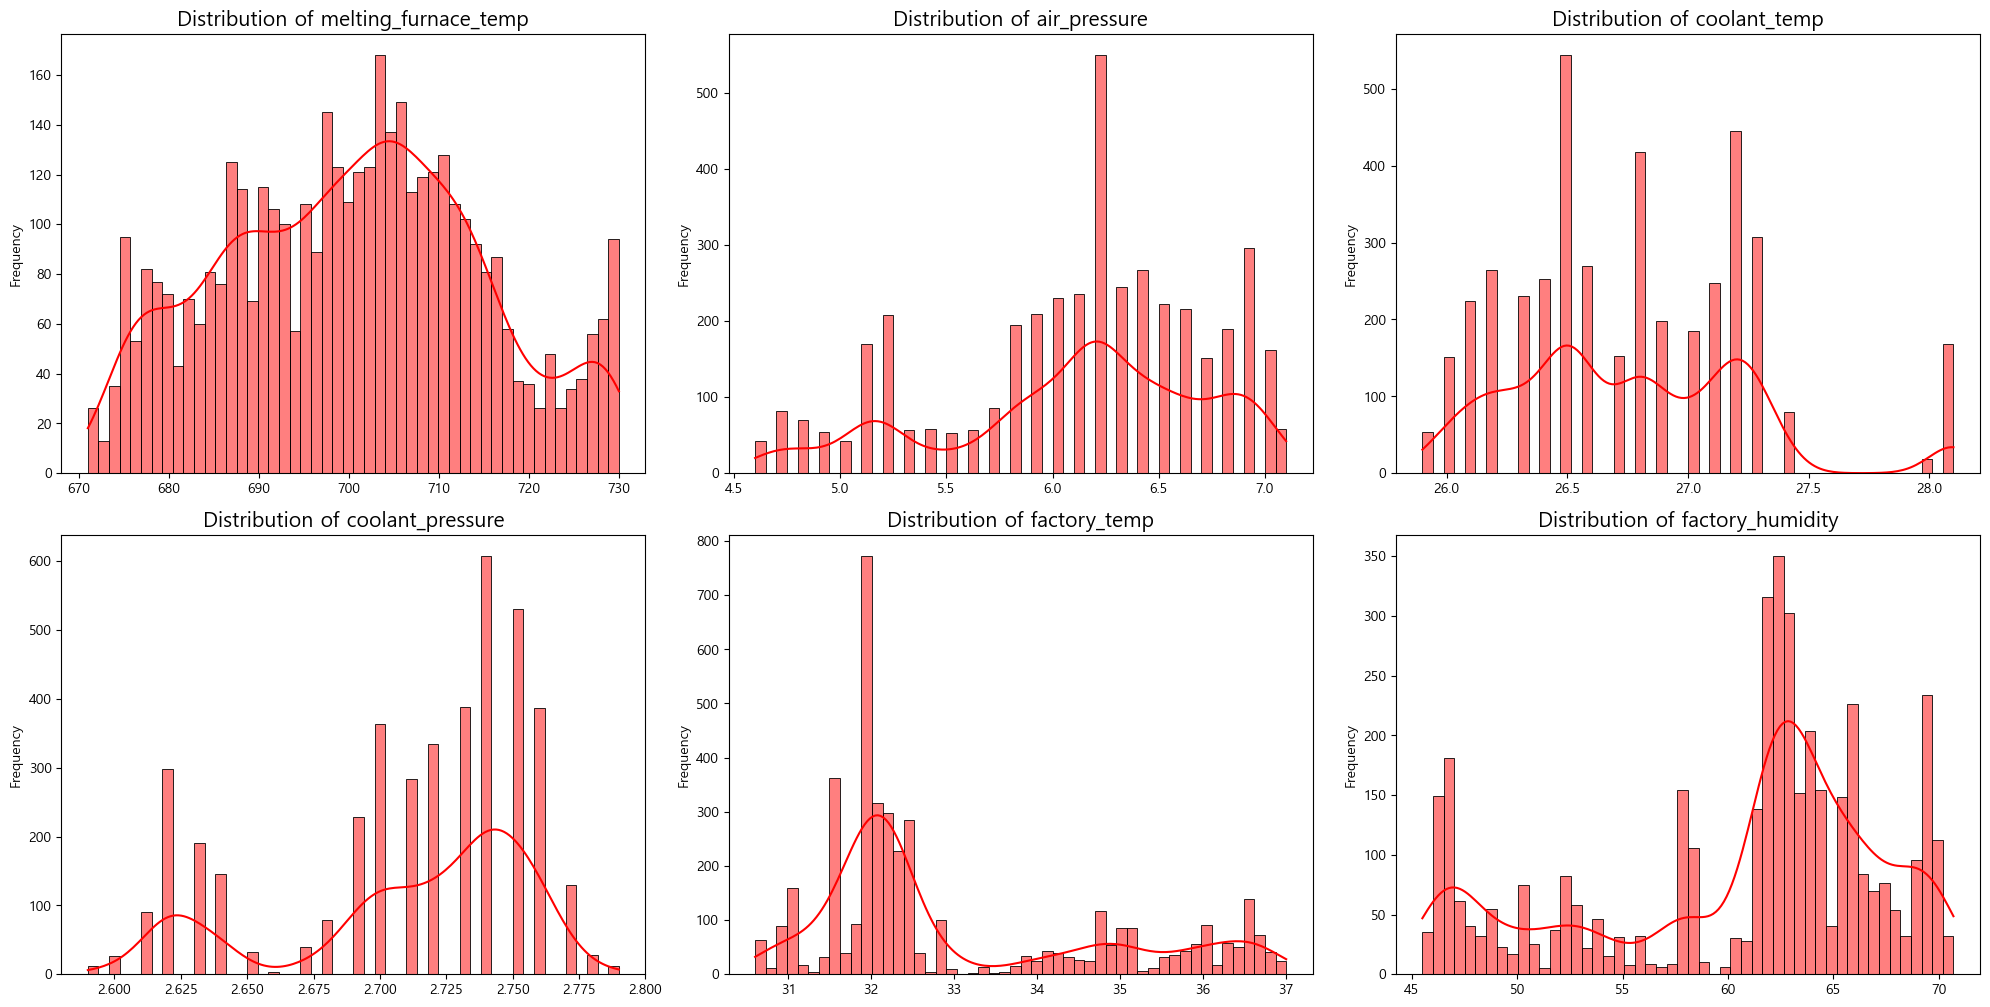

In [31]:
# 1. 수치형 컬럼 추출
numeric_cols = df_sensor_clean.select_dtypes(include=['number']).columns

# 2. 레이아웃 계산
n_cols = 3
n_rows = (len(numeric_cols) - 1 // n_cols + 1)

# 3. 시각화 설정 (figsize는 데이터 컬럼 수에 따라 조절)
plt.figure(figsize=(20, n_rows * 5)) 
plt.subplots_adjust(hspace=0.4)

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    # 수치 데이터만 들어가므로 안전하게 히스토그램 생성
    sns.histplot(df_sensor_clean[col], kde=True, color='red', bins=50)
    plt.title(f'Distribution of {col}', fontsize=15)
    plt.xlabel('') # x축 라벨 생략하여 깔끔하게 표시
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [37]:
# 1. 컬럼 선택
df_sensor_numeric = df_sensor_clean.select_dtypes(include=['number'])
col = df_sensor_numeric.columns

# 2. 이상치 개수를 저장할 딕셔너리
outlier_counts = {}

for col in df_sensor_numeric.columns:
    Q1 = df_sensor_numeric[col].quantile(0.25)
    Q3 = df_sensor_numeric[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 임계값 계산
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 이상치 판정 및 개수 합산
    outliers = df_sensor_numeric[(df_sensor_numeric[col] < lower_bound) | (df_sensor_numeric[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

# 3. 결과 출력
outlier_summary = pd.Series(outlier_counts).sort_values(ascending=False)
print(outlier_summary)

# 4. 비율 확인
outlier_ratio = (outlier_summary / len(df_process_clean) * 100).round(2)
print("\n--- 전체 데이터 대비 이상치 비율 (%) ---")
print(outlier_ratio.head(10))

factory_temp            300
melting_furnace_temp      0
air_pressure              0
coolant_temp              0
coolant_pressure          0
factory_humidity          0
dtype: int64

--- 전체 데이터 대비 이상치 비율 (%) ---
factory_temp            3.98
melting_furnace_temp    0.00
air_pressure            0.00
coolant_temp            0.00
coolant_pressure        0.00
factory_humidity        0.00
dtype: float64


In [38]:
outlier_col_list3 = outlier_summary[outlier_summary > 0].index.tolist()
print("컬럼 리스트:", outlier_col_list3)

컬럼 리스트: ['factory_temp']


In [ ]:
# 혹시 모르니 복사본 만듦
df_cleaned = df_sensor_clean.copy()
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns

for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_cleaned.loc[df_cleaned[col] < lower_bound, col] = lower_bound
    df_cleaned.loc[df_cleaned[col] > upper_bound, col] = upper_bound

In [ ]:
results = []

for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    after_count = ((df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)).sum()
    before_count = ((df_sensor_clean[col] < lower_bound) | (df_sensor_clean[col] > upper_bound)).sum()
    
    results.append({
        'Column': col,
        'Before_Clean': before_count,
        'After_Clean': after_count
    })

comparison_df = pd.DataFrame(results).set_index('Column')
print("--- 이상치 정제 전/후 개수 비교 ---")
print(comparison_df.sort_values(by='Before_Clean', ascending=False))

--- 이상치 정제 전/후 개수 비교 ---
                      Before_Clean  After_Clean
Column                                         
factory_temp                   300            0
melting_furnace_temp             0            0
air_pressure                     0            0
coolant_temp                     0            0
coolant_pressure                 0            0
factory_humidity                 0            0


In [32]:
# Process, Sensor 관련 데이터 확인
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"⬇️{df_name} 관련 데이터의 기초통계량⬇️")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 기본 통계량
    stats_df = df_copied.describe().T
    
    # 고유값의 개수, 왜도, 첨도 추가
    stats_df['Unique'] = df_copied.nunique()
    stats_df['Skewness'] = df_copied.skew()
    stats_df['Kurtosis'] = df_copied.kurtosis()
    
    # 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수', # 결측치가 아닌 값의 개수
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Unique': '고유값',
        'Skewness': '왜도',
        'Kurtosis': '첨도'
    }, inplace=True)
    
    display(stats_df)
    
    return stats_df

In [33]:
# 함수 실행
stats_df_process = create_statistics_summary(df_process, 'Process', exclude_cols=['id', 'Product_Type'])
stats_df_sensor = create_statistics_summary(df_sensor, 'Sensor')


⬇️Process 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
product_type,4207.0,1.000000,0.000000,1.000,1.000,1.000,1.000,1.000,1,0.000000,0.000000
shot,4207.0,542.310197,365.926145,1.000,218.000,503.000,846.000,1296.000,1270,0.322930,-1.093876
velocity_1,4207.0,0.143272,0.004151,0.134,0.142,0.142,0.144,0.180,30,4.422801,26.453943
velocity_2,4207.0,0.168944,0.005202,0.162,0.168,0.168,0.170,0.212,22,5.413094,34.548205
velocity_3,4207.0,0.182449,0.006850,0.172,0.178,0.182,0.186,0.234,38,3.064106,15.636262
high_velocity,4207.0,2.134074,0.081259,0.000,2.120,2.137,2.152,2.285,164,-19.158455,470.207865
cylinder_pressure,4207.0,219.793202,8.888864,107.000,215.000,217.000,218.000,241.000,16,-0.587423,24.254673
rapid_rise_time,4207.0,0.007963,0.001266,0.000,0.008,0.008,0.008,0.021,18,3.769409,31.224279
biscuit_thickness,4207.0,11.715237,1.529924,0.000,11.000,12.000,12.000,22.000,21,-1.761872,16.894330
clamping_force,4207.0,255.877110,2.465235,238.000,254.000,257.000,258.000,263.000,18,-0.895664,4.163840



⬇️Sensor 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
melting_furnace_temp,4207.0,700.388614,14.365077,671.00,689.15,701.20,710.65,730.00,429,0.037698,-0.712042
air_pressure,4207.0,6.100903,0.623627,4.60,5.80,6.20,6.60,7.10,26,-0.588247,-0.429930
air_pressure_min,4207.0,3.000000,0.000000,3.00,3.00,3.00,3.00,3.00,1,0.000000,0.000000
air_pressure_max,4207.0,9.000000,0.000000,9.00,9.00,9.00,9.00,9.00,1,0.000000,0.000000
coolant_temp,4207.0,26.756382,0.491092,25.90,26.40,26.70,27.10,28.10,18,0.628650,0.331310
coolant_temp_min,4207.0,10.000000,0.000000,10.00,10.00,10.00,10.00,10.00,1,0.000000,0.000000
coolant_temp_max,4207.0,50.000000,0.000000,50.00,50.00,50.00,50.00,50.00,1,0.000000,0.000000
coolant_pressure,4207.0,2.710183,0.047140,2.59,2.69,2.72,2.75,2.79,21,-0.870506,-0.387617
factory_temp,4207.0,33.015997,1.748600,30.60,32.00,32.20,34.50,37.00,64,0.935854,-0.523862
factory_temp_min,4207.0,18.000000,0.000000,18.00,18.00,18.00,18.00,18.00,1,0.000000,0.000000
